imports

In [ ]:
import pandas as pd
! pip install pymongo
import pymongo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 9.8 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv")

In [ ]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

Correlation heatmap

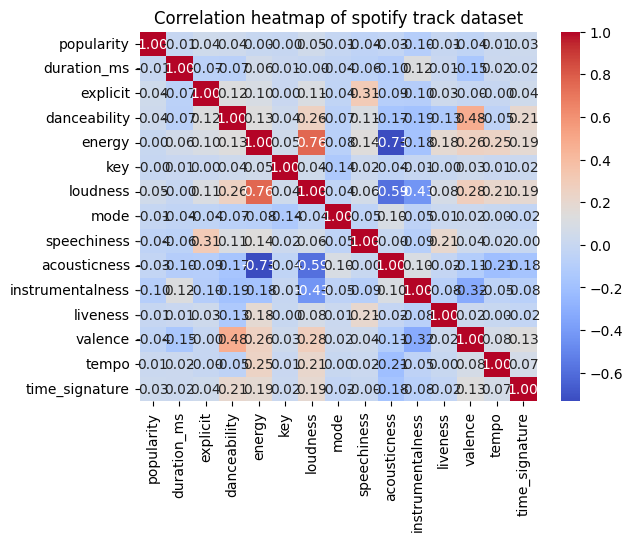

In [ ]:
amended_df = df.drop(columns='Unnamed: 0')

corr = amended_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation heatmap of spotify track dataset')
plt.show()

In [ ]:
df.query('artists.isnull()')

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [ ]:
df['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

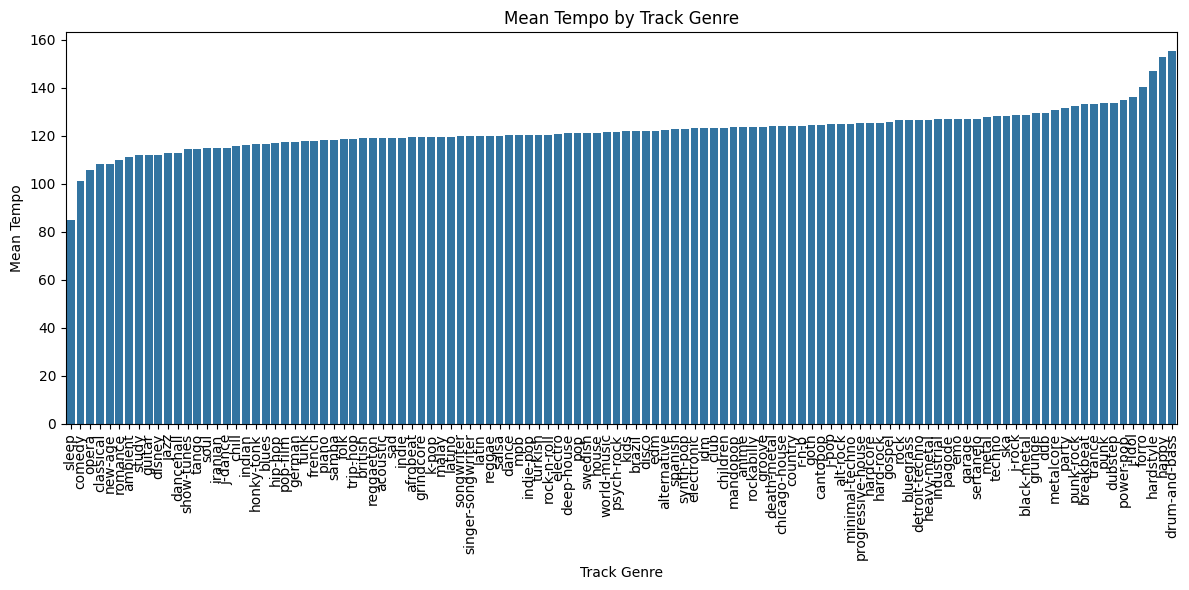

In [ ]:

import matplotlib.pyplot as plt
# Group data by track genre and calculate the mean tempo for each genre
genre_tempo = df.groupby('track_genre')['tempo'].mean().reset_index()

genre_tempo = genre_tempo.sort_values(by='tempo', ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
sns.barplot(x='track_genre', y='tempo', data=genre_tempo)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('Track Genre')
plt.ylabel('Mean Tempo')
plt.title('Mean Tempo by Track Genre')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


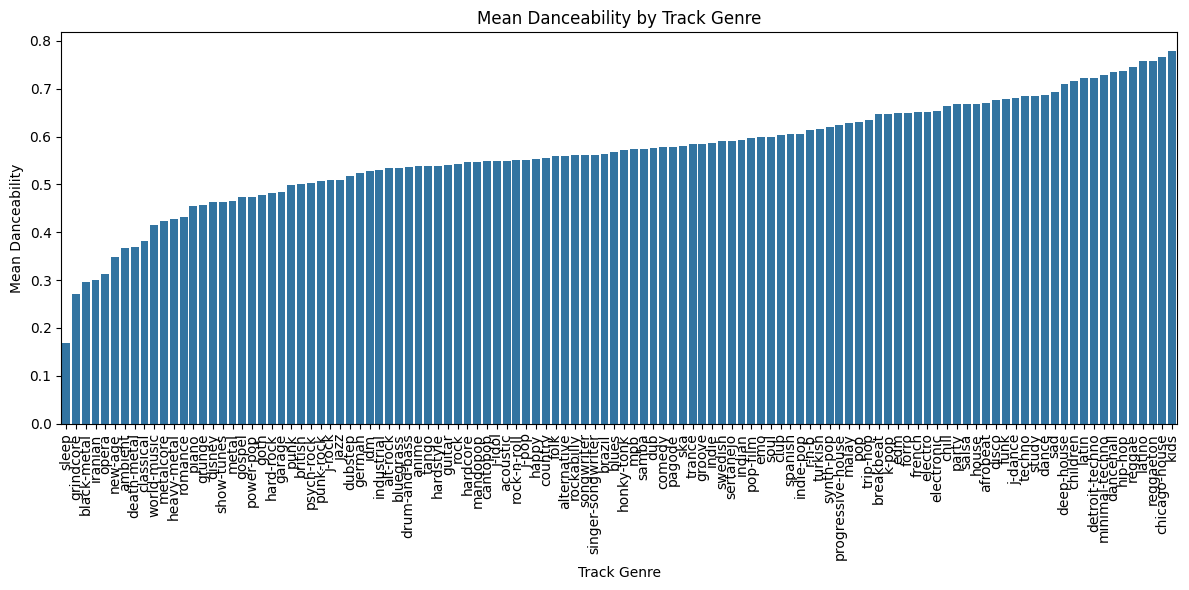

In [ ]:

import matplotlib.pyplot as plt
# Group data by track genre and calculate the mean tempo for each genre
genre_tempo = df.groupby('track_genre')['danceability'].mean().reset_index()

genre_tempo = genre_tempo.sort_values(by='danceability', ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
sns.barplot(x='track_genre', y='danceability', data=genre_tempo)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('Track Genre')
plt.ylabel('Mean Danceability')
plt.title('Mean Danceability by Track Genre')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


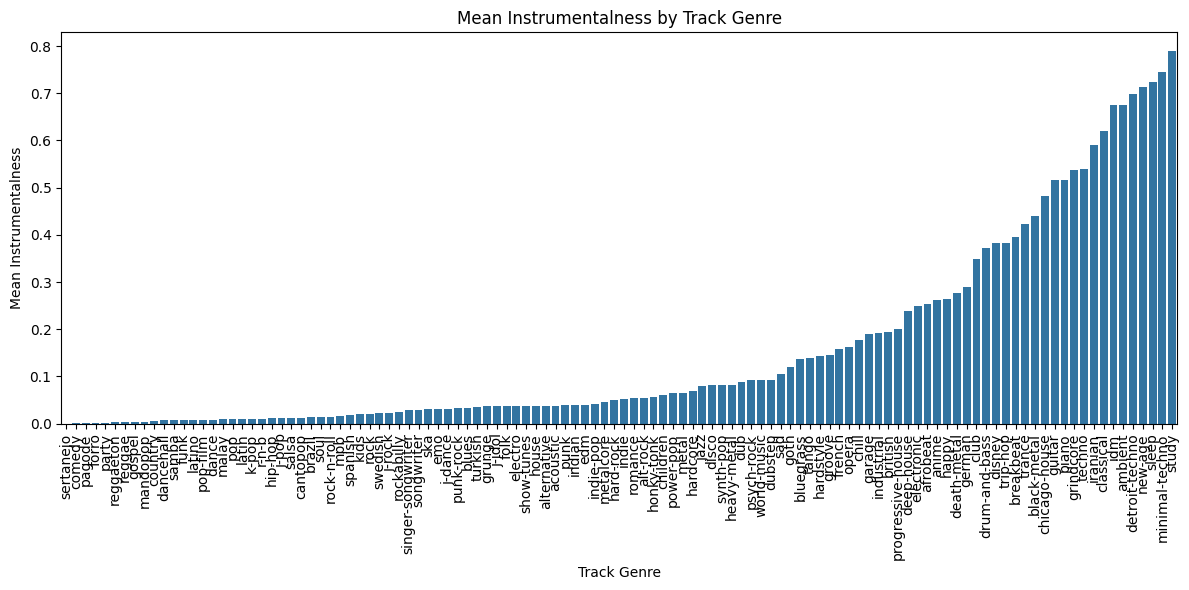

In [ ]:

import matplotlib.pyplot as plt
# Group data by track genre and calculate the mean tempo for each genre
genre_tempo = df.groupby('track_genre')['instrumentalness'].mean().reset_index()

genre_tempo = genre_tempo.sort_values(by='instrumentalness', ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
sns.barplot(x='track_genre', y='instrumentalness', data=genre_tempo)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('Track Genre')
plt.ylabel('Mean Instrumentalness')
plt.title('Mean Instrumentalness by Track Genre')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


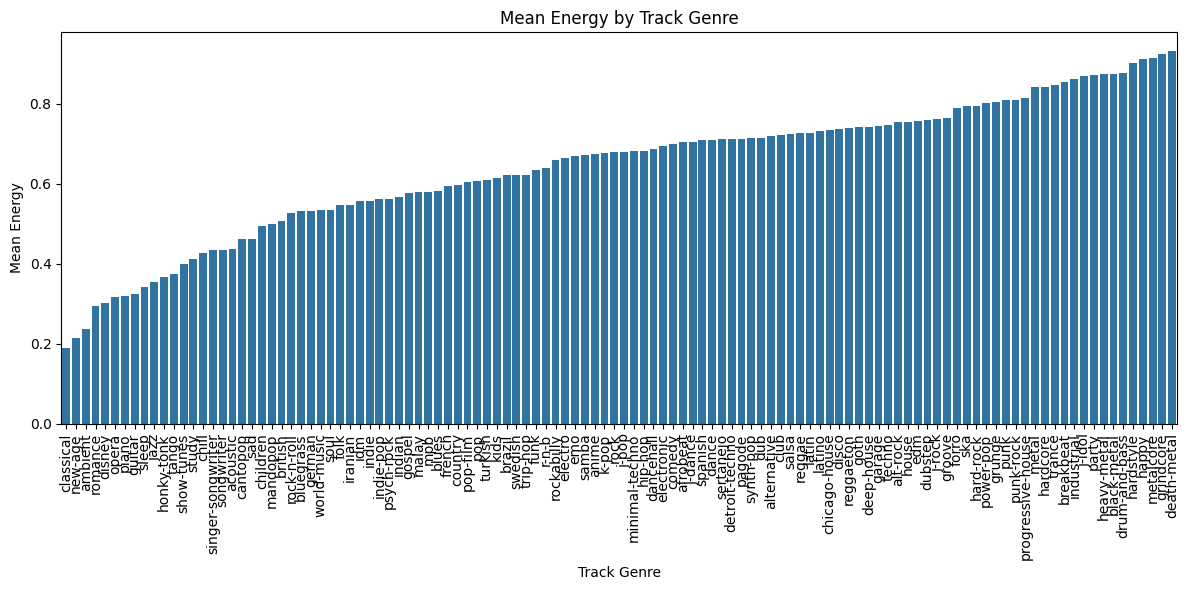

In [ ]:

import matplotlib.pyplot as plt
# Group data by track genre and calculate the mean tempo for each genre
genre_tempo = df.groupby('track_genre')['energy'].mean().reset_index()

genre_tempo = genre_tempo.sort_values(by='energy', ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
sns.barplot(x='track_genre', y='energy', data=genre_tempo)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('Track Genre')
plt.ylabel('Mean Energy')
plt.title('Mean Energy by Track Genre')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


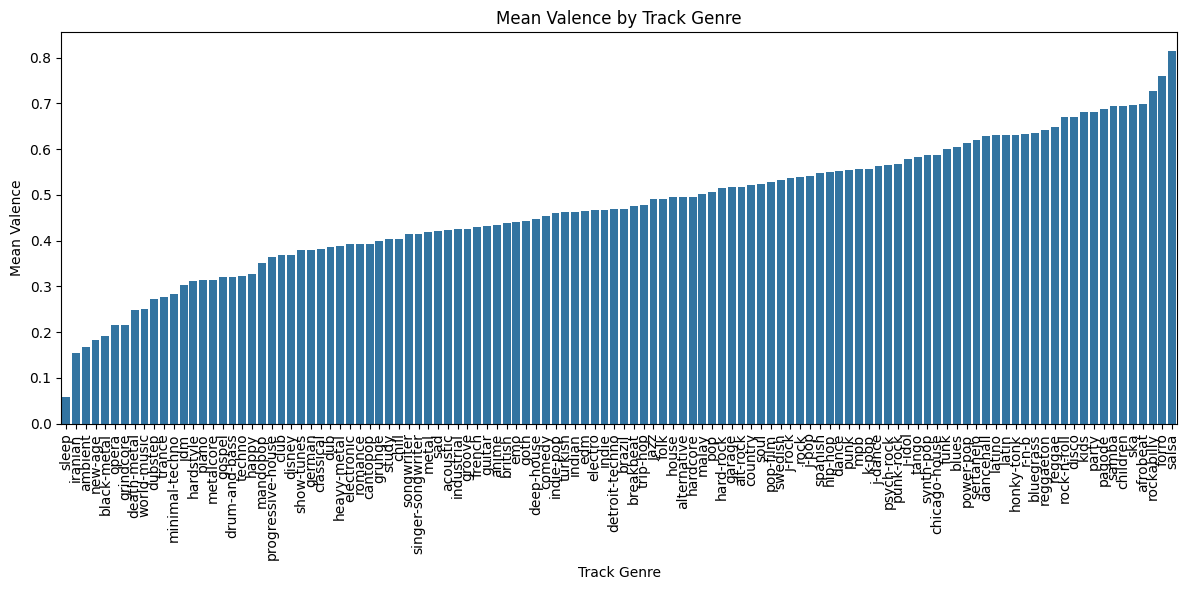

In [ ]:

import matplotlib.pyplot as plt
# Group data by track genre and calculate the mean tempo for each genre
genre_tempo = df.groupby('track_genre')['valence'].mean().reset_index()

genre_tempo = genre_tempo.sort_values(by='valence', ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
sns.barplot(x='track_genre', y='valence', data=genre_tempo)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('Track Genre')
plt.ylabel('Mean Valence')
plt.title('Mean Valence by Track Genre')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


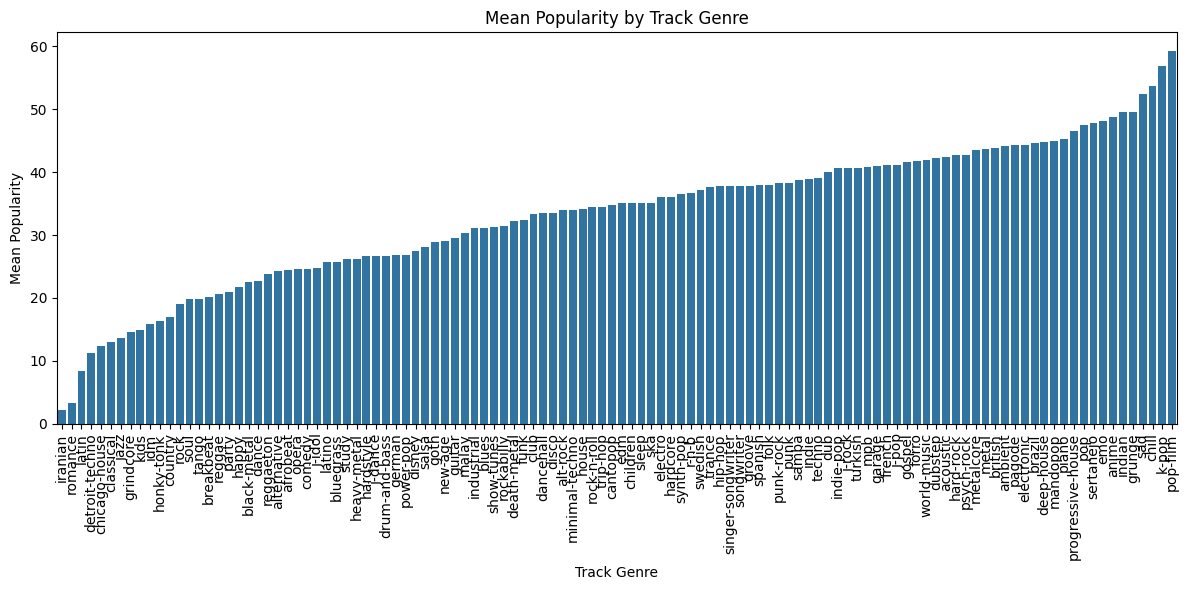

In [ ]:

import matplotlib.pyplot as plt
# Group data by track genre and calculate the mean popularity for each genre
genre_popularity = df.groupby('track_genre')['popularity'].mean().reset_index()

# Sort the data by mean popularity in increasing order
genre_popularity = genre_popularity.sort_values(by='popularity')

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='track_genre', y='popularity', data=genre_popularity)
plt.xticks(rotation=90)
plt.xlabel('Track Genre')
plt.ylabel('Mean Popularity')
plt.title('Mean Popularity by Track Genre')
plt.tight_layout()
plt.show()


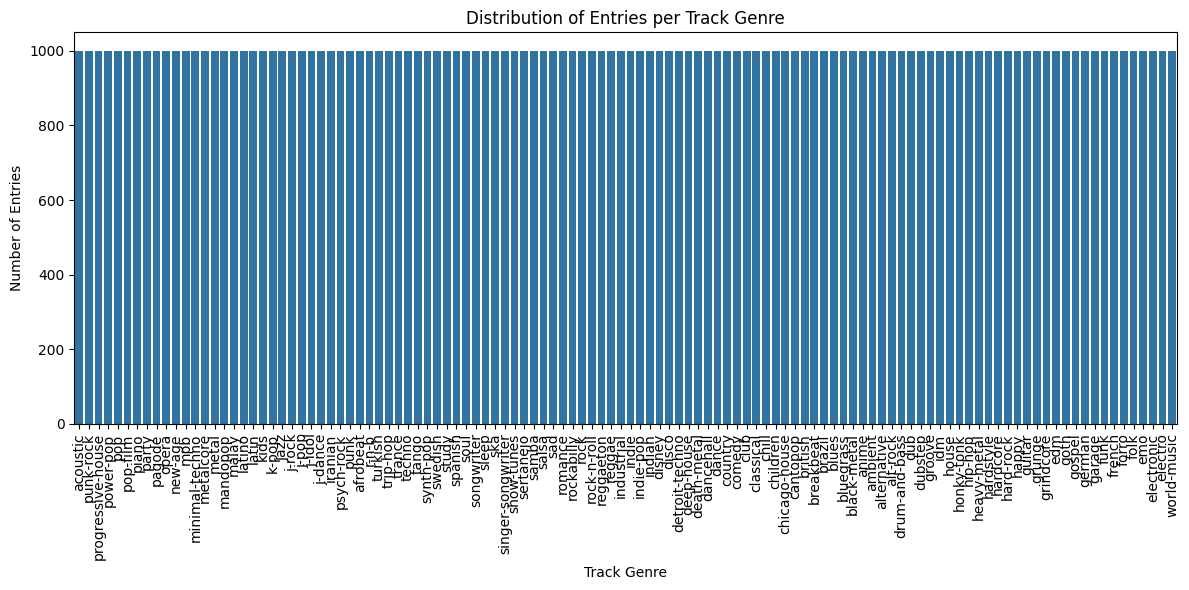

In [ ]:

import matplotlib.pyplot as plt
# Count the occurrences of each track genre
genre_counts = df['track_genre'].value_counts()

# Create a bar plot of the genre counts
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.xticks(rotation=90)
plt.xlabel('Track Genre')
plt.ylabel('Number of Entries')
plt.title('Distribution of Entries per Track Genre')
plt.tight_layout()
plt.show()


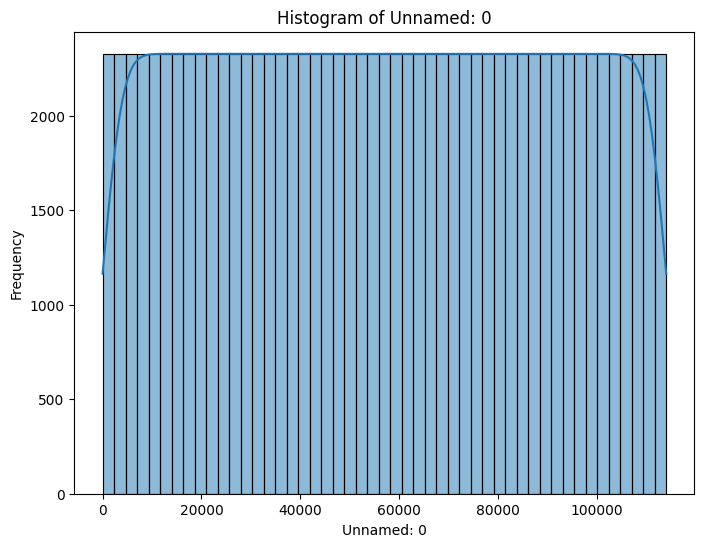

Unnamed: 0: Not skewed


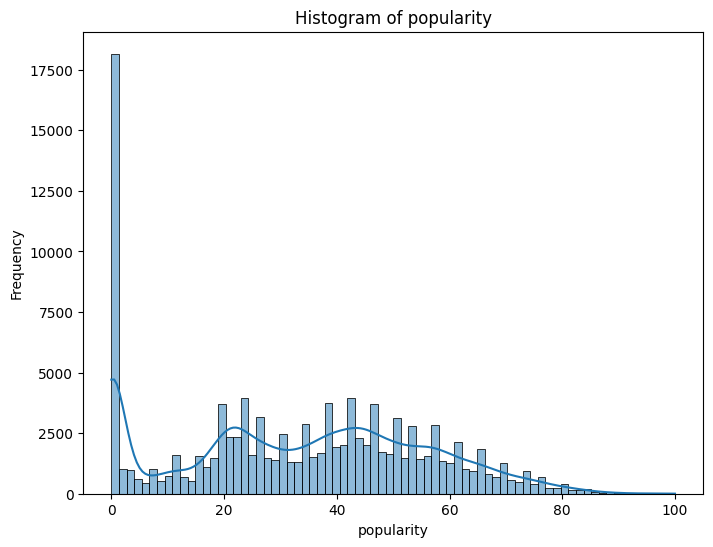

popularity: Not skewed


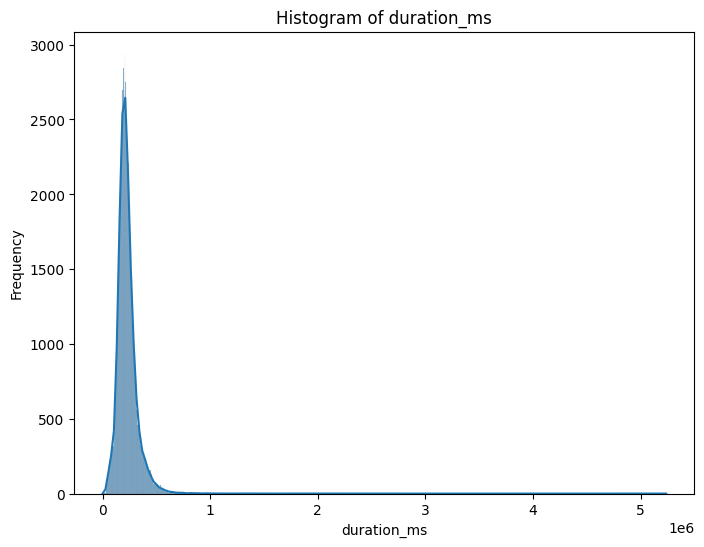

duration_ms: Skewed right


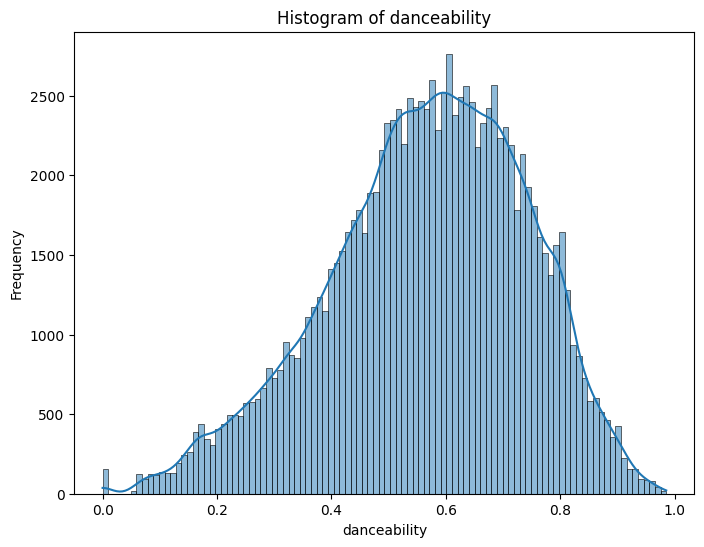

danceability: Not skewed


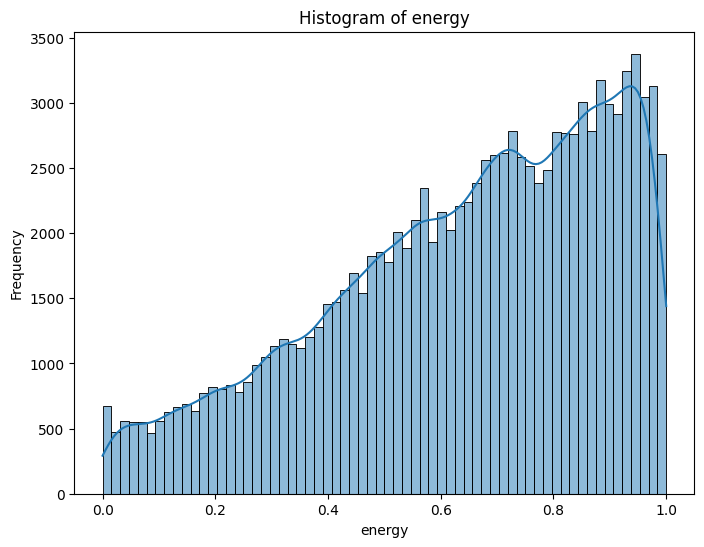

energy: Skewed left


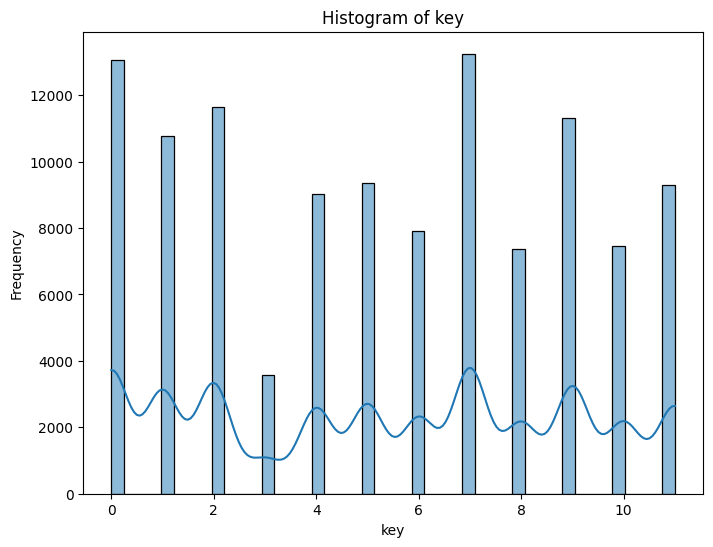

key: Not skewed


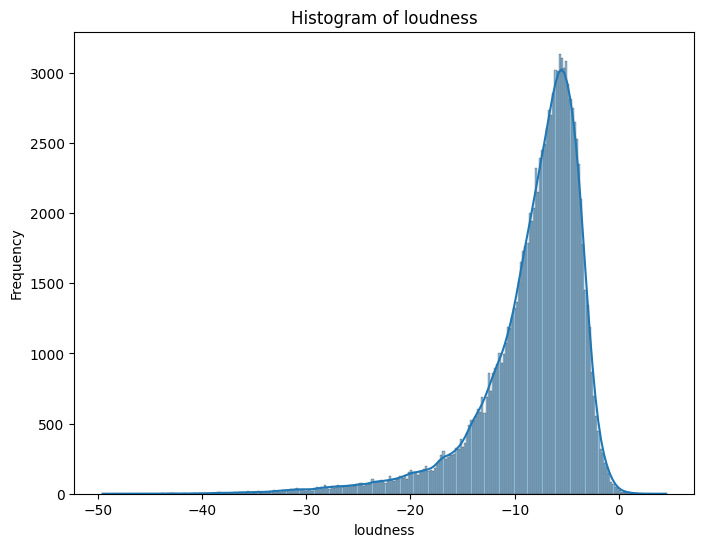

loudness: Skewed left


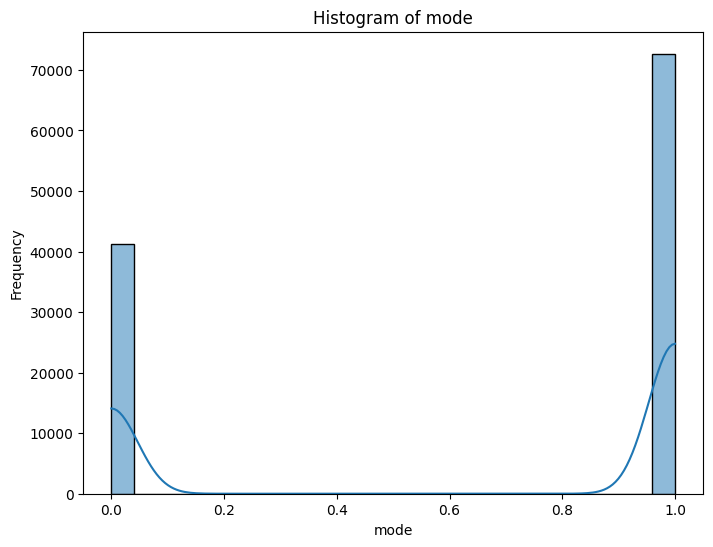

mode: Skewed left


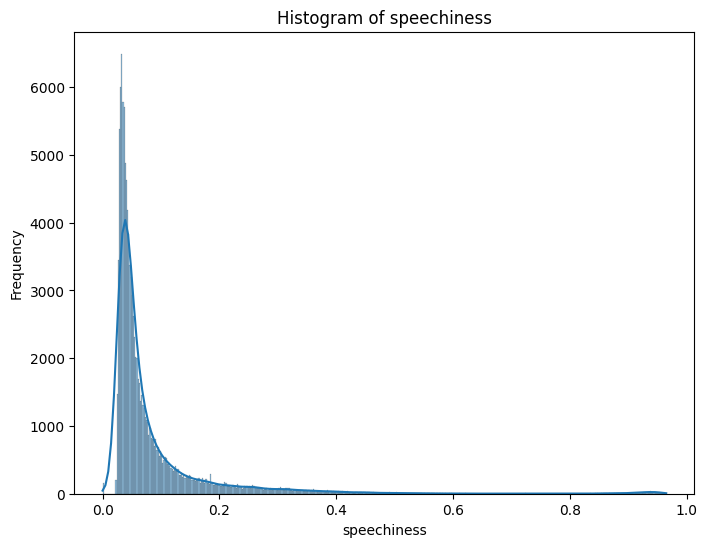

speechiness: Skewed right


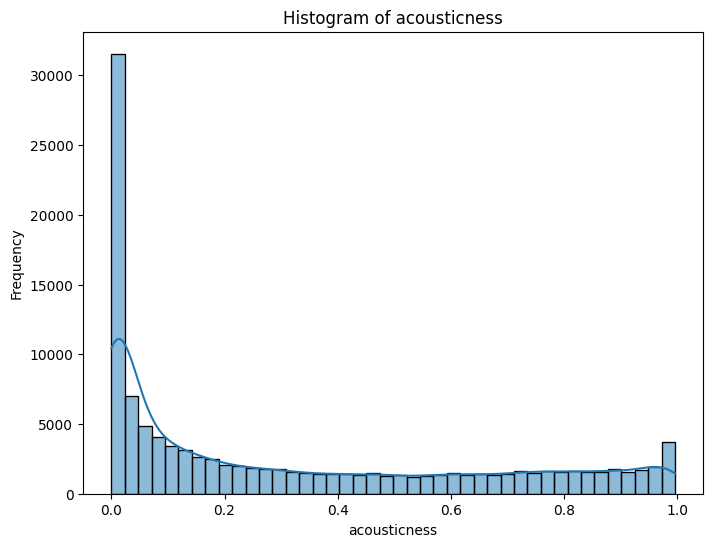

acousticness: Skewed right


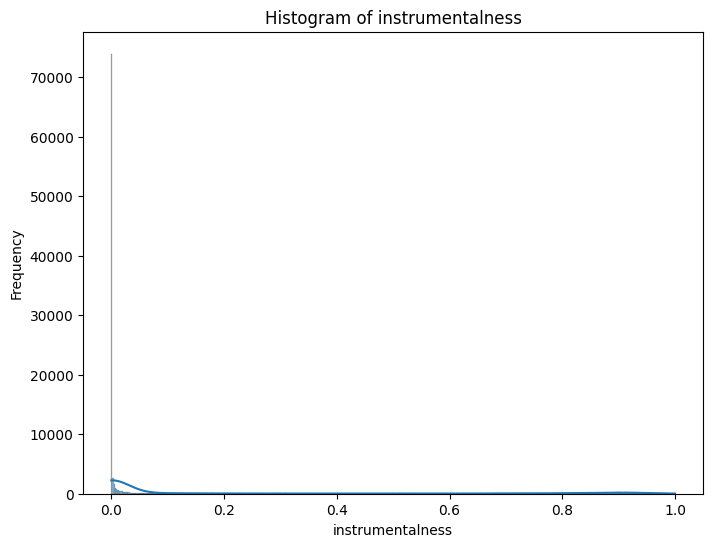

instrumentalness: Skewed right


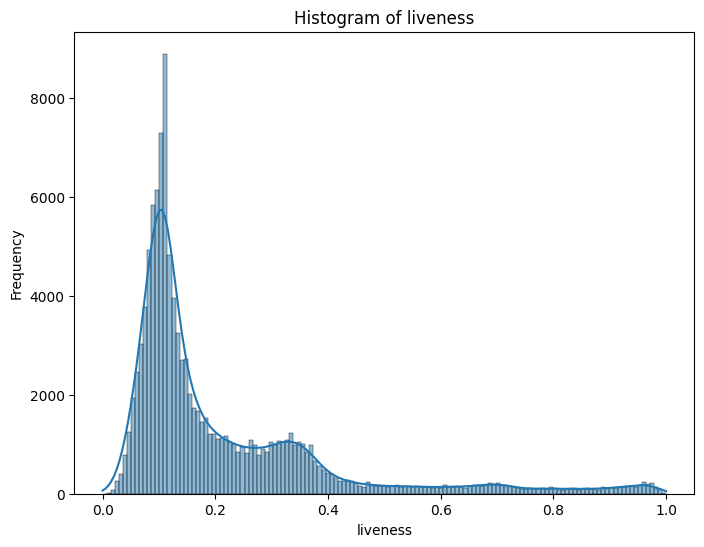

liveness: Skewed right


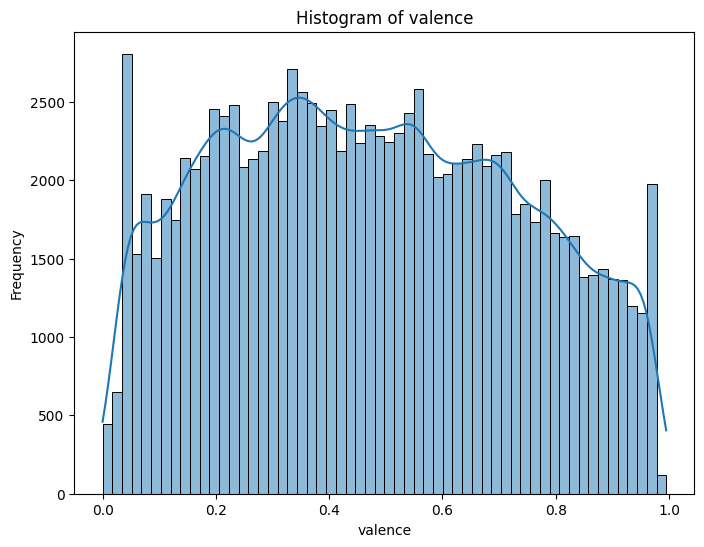

valence: Not skewed


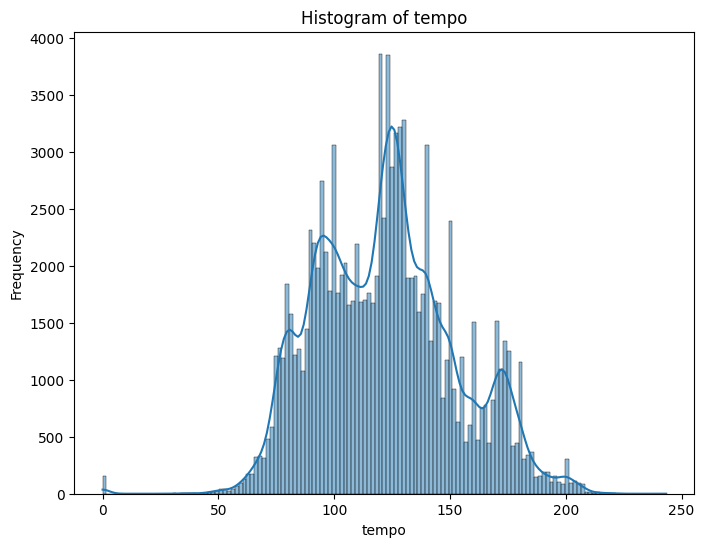

tempo: Not skewed


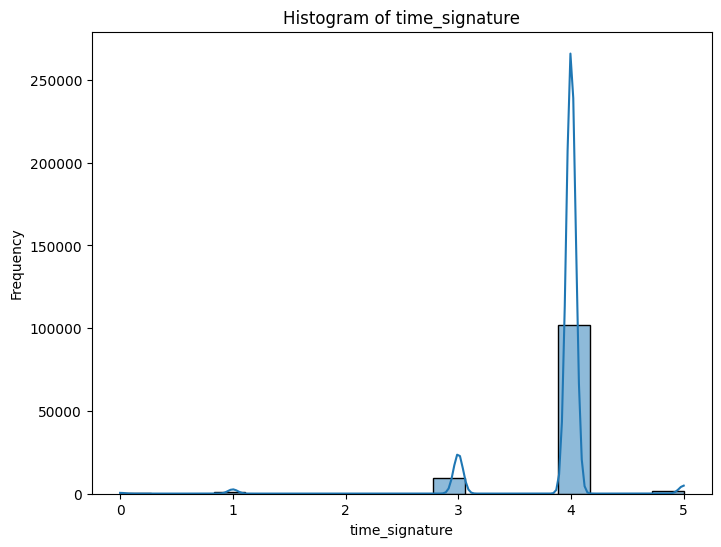

time_signature: Skewed left


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


for col in df.select_dtypes(include=['number']):  # Iterate through numerical columns
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    # Determine skewness
    if df[col].skew() > 0.5:
        print(f'{col}: Skewed right')
    elif df[col].skew() < -0.5:
        print(f'{col}: Skewed left')
    else:
        print(f'{col}: Not skewed')


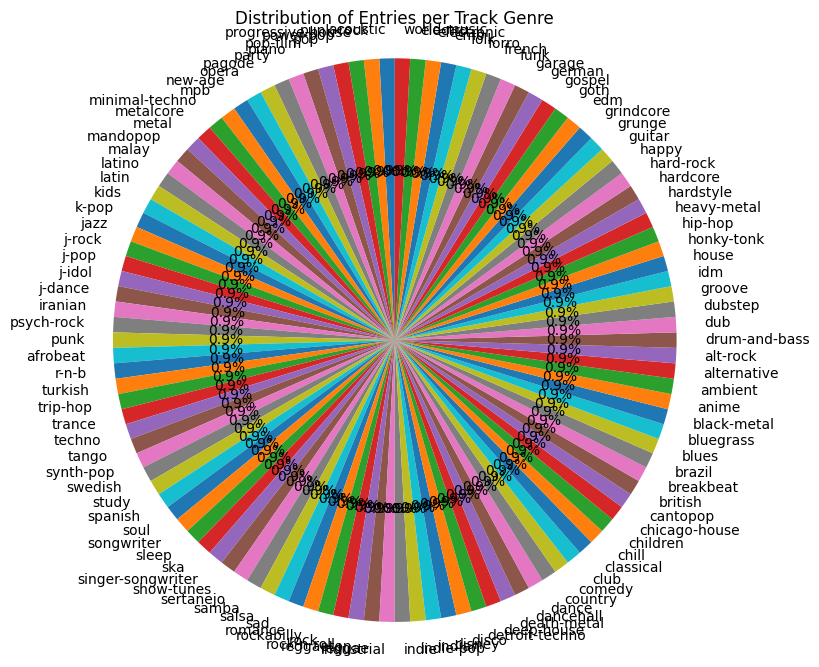

In [ ]:

import matplotlib.pyplot as plt

# Count the occurrences of each track genre
genre_counts = df['track_genre'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Entries per Track Genre')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


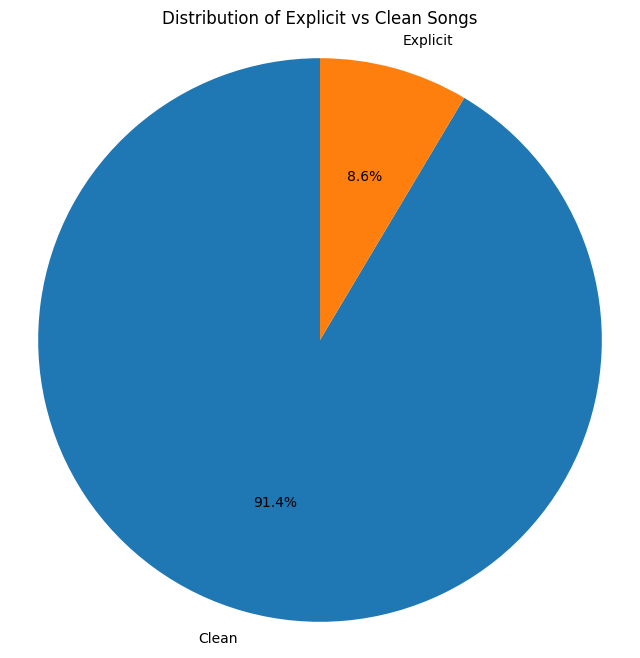

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
# Assuming df is already loaded as in your provided code
# If not, load it here:
# df = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv")

explicit_counts = df['explicit'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(explicit_counts, labels=['Explicit' if label == True else 'Clean' for label in explicit_counts.index], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Explicit vs Clean Songs')
plt.axis('equal')
plt.show()


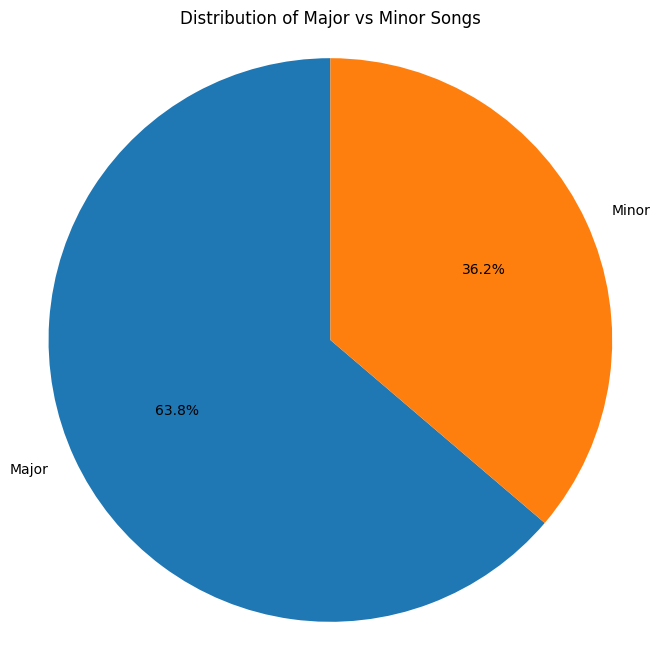

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is already loaded as in your provided code
# If not, load it here:
# df = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv")

explicit_counts = df['mode'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(explicit_counts, labels=['Major' if label == True else 'Minor' for label in explicit_counts.index], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Major vs Minor Songs')
plt.axis('equal')
plt.show()


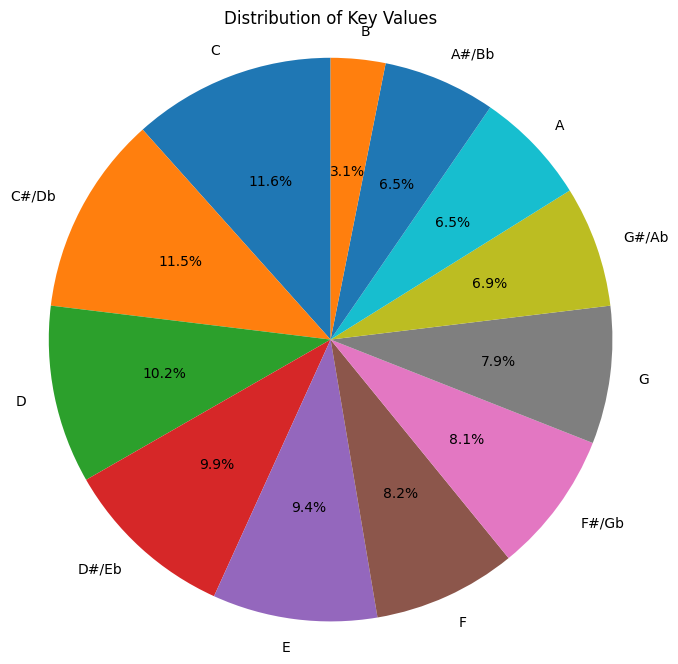

In [ ]:

import matplotlib.pyplot as plt
# Assuming 'key' column exists in your DataFrame 'df'
key_counts = df['key'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(key_counts, labels=[ # Replace with your desired labels
    "C", "C#/Db", "D", "D#/Eb", "E", "F",
    "F#/Gb", "G", "G#/Ab", "A", "A#/Bb", "B"
    ], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Key Values')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


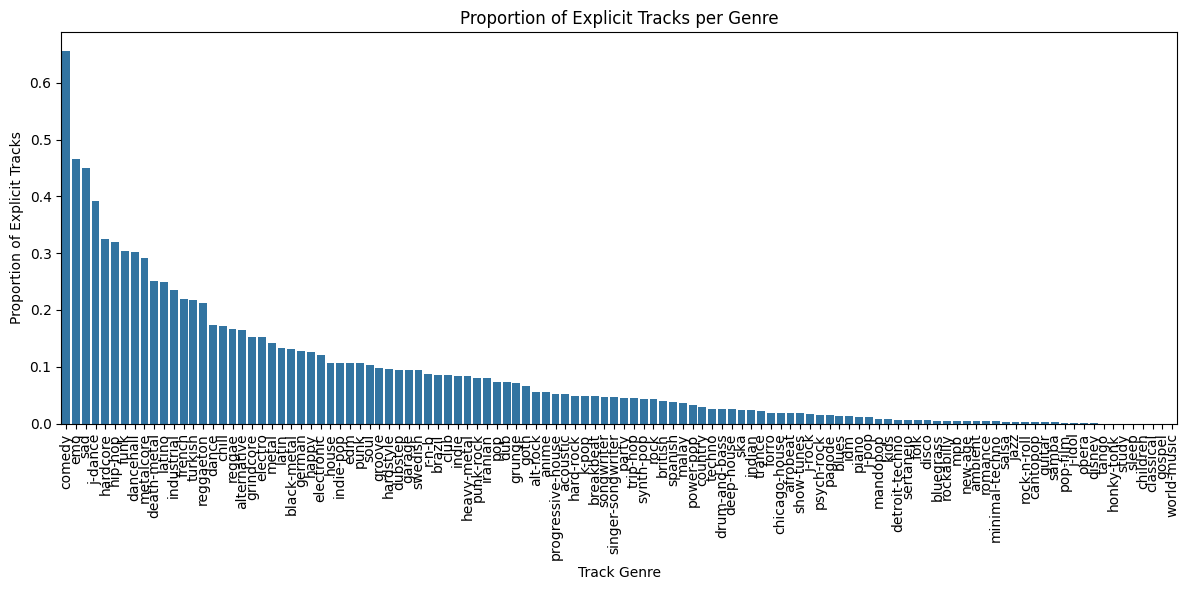

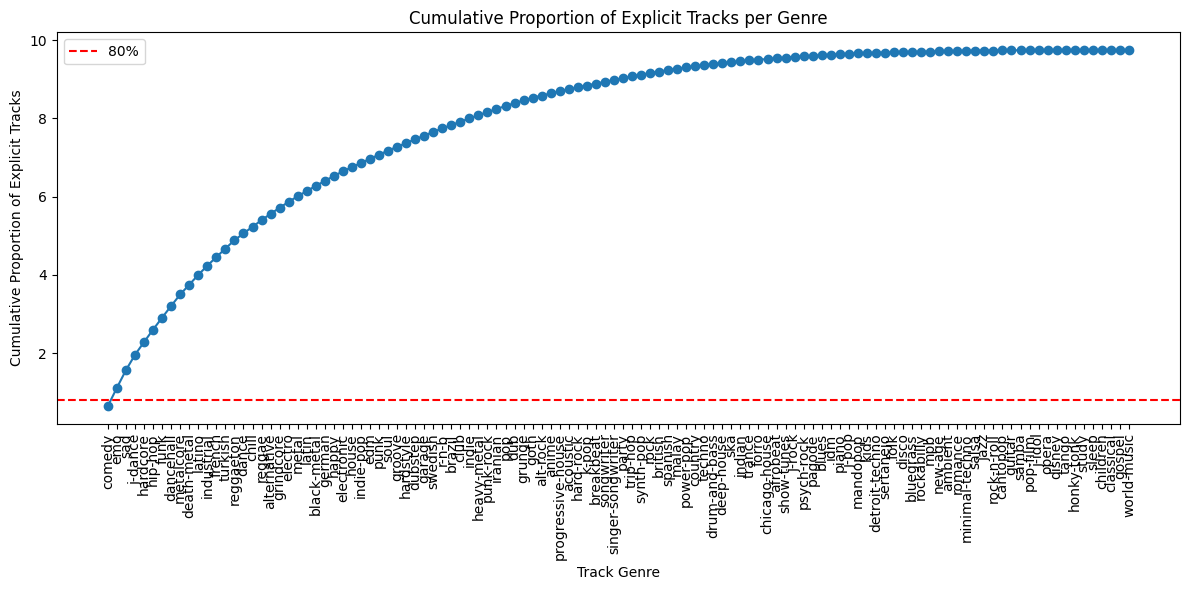

In [ ]:

import matplotlib.pyplot as plt

# Calculate the proportion of explicit tracks per genre
explicit_proportion = df.groupby('track_genre')['explicit'].mean().reset_index()

# Sort the genres by proportion of explicit tracks in descending order
explicit_proportion = explicit_proportion.sort_values(by='explicit', ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='track_genre', y='explicit', data=explicit_proportion)
plt.xticks(rotation=90)
plt.xlabel('Track Genre')
plt.ylabel('Proportion of Explicit Tracks')
plt.title('Proportion of Explicit Tracks per Genre')
plt.tight_layout()
plt.show()

# Calculate the cumulative proportion of explicit tracks
explicit_proportion['cumulative_proportion'] = explicit_proportion['explicit'].cumsum()

# Plot the cumulative proportion
plt.figure(figsize=(12, 6))
plt.plot(explicit_proportion['track_genre'], explicit_proportion['cumulative_proportion'], marker='o')
plt.xticks(rotation=90)
plt.xlabel('Track Genre')
plt.ylabel('Cumulative Proportion of Explicit Tracks')
plt.title('Cumulative Proportion of Explicit Tracks per Genre')

# Add a horizontal line at 0.8 to visualize the 80-20 rule
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.legend()

plt.tight_layout()
plt.show()
